# Часть 2. Синтетика и сравнение веток

Q1: можно ли заменить real на synth (TimeGAN/CTGAN)?
Q2: помогает ли смешивание real + synth?

Ветки: B2-TimeGAN, B2-CTGAN, B3-Augmented. Сравниваем с эталоном B1 из части 1.

> ⚠️ Прогон полный: TimeGAN ~5–10 мин на CUDA, CTGAN ~2–3 мин на CPU. Сид зафиксирован — числа воспроизводимы.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from src import data as dm
from src import garch_eval as ge
from src import stylized as sf
from src import timegan as tg
from src import ctgan_wrapper as cgw

SEED = 42
SCALE = ge.SCALE
ART = ROOT / "artifacts"

def set_seed(s=SEED):
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

set_seed()

# перезагружаем данные и эталон из части 1
prices, returns = dm.load_or_download()
train, test = dm.train_test_split(returns)
params_real = ge.GarchParams(**json.loads((ART / "garch_params_real.json").read_text(encoding="utf-8")))
metrics_b1 = json.loads((ART / "metrics_B1.json").read_text(encoding="utf-8"))
df_b1 = pd.read_csv(ART / "forecasts_B1.csv", index_col=0, parse_dates=True)
print(f"train: {len(train)}, test: {len(test)}, device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

train: 2515, test: 1258, device: cuda


## TimeGAN

Архитектура для временных рядов: GRU-модули Embedder/Recovery/Generator/Supervisor/Discriminator. Loss как в статье Yoon 2019 (BCE-GAN + supervised + reconstruction).

In [2]:
cfg_tg = tg.TimeGANConfig(
    seq_len=24, hidden_dim=24, num_layers=2, batch_size=128,
    ae_epochs=400, sup_epochs=300, joint_epochs=400, lr=1e-3,
)
real_pct = train.values.astype(np.float32) * SCALE

set_seed()
synth_tg, hist_tg, _ = tg.fit_and_sample(real_pct, n_target=len(train), cfg=cfg_tg, verbose=False)

pd.Series(synth_tg, name="synth_pct").to_csv(ART / "synth_timegan.csv", index=False)
print(f"synth_tg: {len(synth_tg)} обс., last loss: ae={hist_tg['ae_loss'][-1]:.4f}, "
      f"sup={hist_tg['sup_loss'][-1]:.4f}, D={hist_tg['d_loss'][-1]:.3f}, G={hist_tg['g_loss'][-1]:.3f}")

synth_tg: 2515 обс., last loss: ae=0.0000, sup=0.0024, D=1.389, G=0.877


In [3]:
# стилизованные факты real vs synth_TimeGAN
sf_real = sf.stylized_facts(train.values * SCALE, name="real_train")
sf_tg = sf.stylized_facts(synth_tg, name="synth_timegan")

cmp_keys = ["std", "skew", "kurtosis_excess", "min", "max",
            "acf1_abs_returns", "acf5_abs_returns", "acf10_abs_returns"]
cmp_tg = pd.DataFrame({"real": [sf_real[k] for k in cmp_keys],
                       "TimeGAN": [sf_tg[k] for k in cmp_keys]}, index=cmp_keys).round(3)
print(cmp_tg)
# хвосты обрезаны (kurt_excess < 0, |min/max| ~ 1.5 vs 7), ACF |r| на лагах 5/10 умерли -> кластеры утрачены.

                    real  TimeGAN
std                0.932    0.931
skew              -0.497   -0.052
kurtosis_excess    4.597   -1.566
min               -6.896   -1.784
max                4.840    1.427
acf1_abs_returns   0.214    0.210
acf5_abs_returns   0.201   -0.024
acf10_abs_returns  0.200    0.011


In [4]:
params_tg, _ = ge.fit_garch_const_mean(pd.Series(synth_tg / SCALE), dist="t")
df_b2tg = ge.walk_forward_fixed(params_tg, history=train, test=test)
m_b2tg = ge.evaluate_forecast(df_b2tg, params_tg)

p = params_tg.to_dict(); p["alpha+beta"] = p["alpha"] + p["beta"]
print("GARCH params (B2-TimeGAN):")
print(pd.Series({k: round(v, 4) for k, v in p.items() if isinstance(v, (int, float))}))
print("\nMetrics:")
print(pd.Series({k: round(m_b2tg[k], 4) for k in ["RMSE_abs_r", "QLIKE", "MZ_b",
                                                   "VaR5_rate", "VaR1_rate"]}))
# beta -> 0 (память умерла), nu -> очень большое (хвостов нет), MZ_b сильно > 1.
# VaR(1%) пробит ~ в 2 раза от нормы -> опасная недооценка крайнего риска.

GARCH params (B2-TimeGAN):
mu             -0.0288
omega           0.6935
alpha           0.2025
beta            0.0000
nu            499.9808
alpha+beta      0.2025
dtype: float64

Metrics:
RMSE_abs_r    0.9378
QLIKE         1.4460
MZ_b          2.4192
VaR5_rate     0.0723
VaR1_rate     0.0350
dtype: float64


## CTGAN

GAN для табличных данных. Здесь намеренно используем "не туда": режем ряд на окна 24 дня и подаём как таблицу. Контрольный плохой пример.

In [5]:
set_seed()
synth_ct, _ = cgw.fit_and_sample_ctgan(real_pct, n_target=len(train), seq_len=24, epochs=300, verbose=False)
pd.Series(synth_ct, name="synth_pct").to_csv(ART / "synth_ctgan.csv", index=False)

sf_ct = sf.stylized_facts(synth_ct, name="synth_ctgan")
cmp_ct = pd.DataFrame({"real": [sf_real[k] for k in cmp_keys],
                       "CTGAN": [sf_ct[k] for k in cmp_keys]}, index=cmp_keys).round(3)
print(cmp_ct)
# распределение в принципе сохранено (kurt, skew, размах ок), НО ACF |r| ~ 0 на всех лагах -> кластеры волатильности убиты.

                    real  CTGAN
std                0.932  1.367
skew              -0.497 -0.536
kurtosis_excess    4.597  3.583
min               -6.896 -8.664
max                4.840  7.145
acf1_abs_returns   0.214 -0.007
acf5_abs_returns   0.201  0.002
acf10_abs_returns  0.200 -0.037


In [6]:
try:
    params_ct, _ = ge.fit_garch_const_mean(pd.Series(synth_ct / SCALE), dist="t")
except Exception as e:
    print(f"GARCH-t failed ({e}); fallback normal")
    params_ct, _ = ge.fit_garch_const_mean(pd.Series(synth_ct / SCALE), dist="normal")

df_b2ct = ge.walk_forward_fixed(params_ct, history=train, test=test)
m_b2ct = ge.evaluate_forecast(df_b2ct, params_ct)

p = params_ct.to_dict(); p["alpha+beta"] = p["alpha"] + (p["beta"] or 0.0)
print("GARCH params (B2-CTGAN):")
print(pd.Series({k: round(v, 4) for k, v in p.items() if isinstance(v, (int, float))}))
print("\nMetrics:")
print(pd.Series({k: round(m_b2ct[k], 4) for k in ["RMSE_abs_r", "QLIKE", "MZ_b",
                                                   "VaR5_rate", "VaR1_rate"]}))
# alpha ~ 0 (нет реакции на удары), omega огромное -> прогноз ≈ const ≈ средний |r|.
# RMSE худший. НО VaR-rate "идеальные" — это ловушка: константная модель формально
# проходит Купика, но не отслеживает COVID-март и пр. См. график ниже.

GARCH params (B2-CTGAN):
mu            0.0503
omega         1.1822
alpha         0.0000
beta          0.4420
nu            3.3496
alpha+beta    0.4420
dtype: float64

Metrics:
RMSE_abs_r    1.168200e+00
QLIKE         1.609800e+00
MZ_b          8.829097e+11
VaR5_rate     4.530000e-02
VaR1_rate     9.500000e-03
dtype: float64


## B3 — Аугментация (real + synth_TimeGAN)

Не заменяем real, а дополняем его TimeGAN-синтетикой и обучаем GARCH на объединённой выборке.

In [7]:
aug_values = np.concatenate([synth_tg / SCALE, train.values])
aug_index = pd.date_range(end=train.index.max(), periods=len(aug_values), freq="B")
aug_series = pd.Series(aug_values, index=aug_index, name="aug")

params_aug, _ = ge.fit_garch_const_mean(aug_series, dist="t")
df_b3 = ge.walk_forward_fixed(params_aug, history=train, test=test)
m_b3 = ge.evaluate_forecast(df_b3, params_aug)

p = params_aug.to_dict(); p["alpha+beta"] = p["alpha"] + p["beta"]
print("GARCH params (B3-aug):")
print(pd.Series({k: round(v, 4) for k, v in p.items() if isinstance(v, (int, float))}))
print("\nMetrics:")
print(pd.Series({k: round(m_b3[k], 4) for k in ["RMSE_abs_r", "QLIKE", "MZ_b",
                                                 "VaR5_rate", "VaR1_rate"]}))
# omega/alpha/beta остались здоровыми, НО nu сильно подскочило (хвосты ослабли -
# синтетика их обрезала). Среднее качество чуть лучше эталона, VaR(1%) хуже.

GARCH params (B3-aug):
mu             0.0336
omega          0.0307
alpha          0.1410
beta           0.8261
nu            75.9599
alpha+beta     0.9671
dtype: float64

Metrics:
RMSE_abs_r    0.8686
QLIKE         1.0896
MZ_b          1.0486
VaR5_rate     0.0668
VaR1_rate     0.0254
dtype: float64


## Сводка

In [8]:
def row(p, m):
    d = p.to_dict()
    d["alpha+beta"] = d["alpha"] + (d.get("beta") or 0.0)
    keep_p = ["omega", "alpha", "beta", "alpha+beta", "nu"]
    keep_m = ["RMSE_abs_r", "QLIKE", "MZ_b", "VaR5_rate", "VaR1_rate"]
    return {**{k: round(d[k], 4) if d.get(k) is not None else None for k in keep_p},
            **{k: round(m[k], 4) for k in keep_m}}

summary = pd.DataFrame({
    "B1 (real)":     row(params_real, metrics_b1),
    "B2 (TimeGAN)":  row(params_tg,   m_b2tg),
    "B2 (CTGAN)":    row(params_ct,   m_b2ct),
    "B3 (aug)":      row(params_aug,  m_b3),
}).T
summary

,omega,alpha,beta,alpha+beta,nu,RMSE_abs_r,QLIKE,MZ_b,VaR5_rate,VaR1_rate
B1 (real),0.0253,0.1759,0.8126,0.9884,4.8739,0.8867,1.0898,9.002000e-01,0.0787,0.0159
B2 (TimeGAN),0.6935,0.2025,0.0000,0.2025,499.9808,0.9378,1.4460,2.419200e+00,0.0723,0.0350
B2 (CTGAN),1.1822,0.0000,0.4420,0.4420,3.3496,1.1682,1.6098,8.829097e+11,0.0453,0.0095
B3 (aug),0.0307,0.1410,0.8261,0.9671,75.9599,0.8686,1.0896,1.048600e+00,0.0668,0.0254


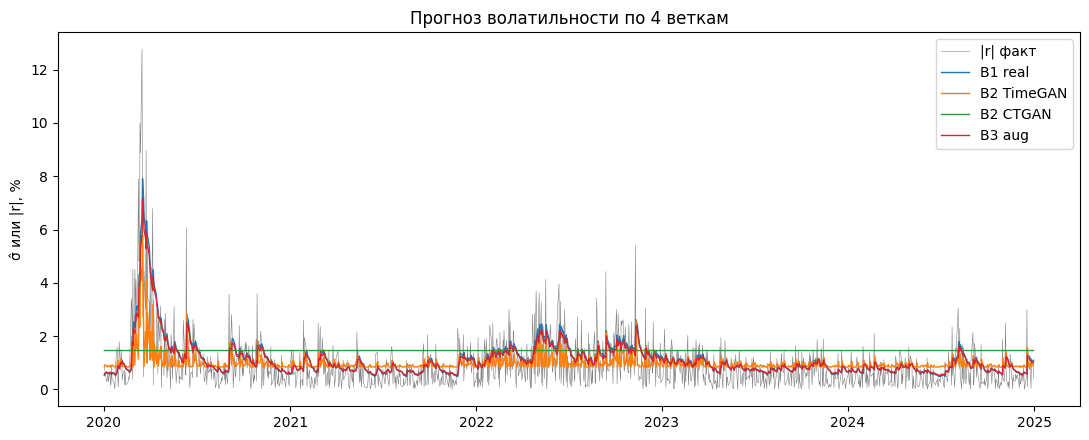

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(test.index, np.abs(test.values * SCALE), lw=0.4, color="black", alpha=0.5, label="|r| факт")
ax.plot(test.index, df_b1["sigma_pct"],  lw=1.0, label="B1 real")
ax.plot(test.index, df_b2tg["sigma_pct"], lw=1.0, label="B2 TimeGAN")
ax.plot(test.index, df_b2ct["sigma_pct"], lw=1.0, label="B2 CTGAN")
ax.plot(test.index, df_b3["sigma_pct"],   lw=1.0, label="B3 aug")
ax.set_ylabel("σ̂ или |r|, %"); ax.set_title("Прогноз волатильности по 4 веткам")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()
# CTGAN — почти прямая линия (модель-константа), TimeGAN сильно дёрганая, B1 и B3 близки.

In [10]:
# сохраняем результаты
for name, p, m, df in [
    ("synth_timegan", params_tg, m_b2tg, df_b2tg),
    ("synth_ctgan",   params_ct, m_b2ct, df_b2ct),
    ("aug",           params_aug, m_b3, df_b3),
]:
    (ART / f"garch_params_{name}.json").write_text(
        json.dumps(p.to_dict(), indent=2, ensure_ascii=False), encoding="utf-8")
    df.to_csv(ART / f"forecasts_{name}.csv")
summary.to_csv(ART / "metrics_summary.csv")
print("saved to artifacts/")

saved to artifacts/


## Выводы

**Q1 (замена real → synth): нельзя.**
- TimeGAN: β≈0, ν очень велико → память и хвосты потеряны. На тесте RMSE и MZ_b хуже эталона, VaR(1%) пробит ~ в 2 раза от нормы.
- CTGAN: α≈0, ω велико → модель почти-константа. RMSE худший. Низкие VaR-rate — артефакт постоянного прогноза, а не свойство модели.

**Q2 (аугментация): смешанный эффект.**
- omega/alpha/beta остаются здоровыми (доминирует реальная половина выборки).
- nu сильно подскакивает — синтетика разбавила хвосты.
- Среднее качество (RMSE, MZ_b) чуть лучше эталона; VaR(5%) ближе к норме; **VaR(1%) — хуже**.
- Для риск-задач, где важен крайний риск, такая аугментация опасна.

**Главное.** «Похожая» синтетика ≠ полезная для GARCH. Без воспроизведения трёх свойств (кластеры, тяжёлые хвосты, асимметрия) GARCH либо ломается, либо вырождается в константу. Ни один из готовых GAN из коробки этого требования не удовлетворил.